# Tomography Tutorial
*Cedric Lim, March 3, 2026*

This tutorial shows the usage of `TomographyLite` for conventional and machine-learning enabled reconstruction methods. These methods abstract arguments in the instantiation of the top-level `Tomography` class, i.e instantiation of object and dataset models. 

In [1]:
%load_ext autoreload
%autoreload 2

# %load_ext tensorboard
# %tensorboard --logdir ../../../outputs/tomography/tutorial_02_notebooks

In [2]:
from quantem.tomography.tomography import TomographyConventional, Tomography
from quantem.tomography.dataset_models import TomographyPixDataset, TomographyINRDataset, TomographyINRPretrainDataset, DatasetConstraintParams
from quantem.tomography.object_models import ObjectINR, ObjectPixelated, ObjConstraintParams
from quantem.tomography.logger_tomography import LoggerTomography
from quantem.core.ml.inr import HSiren
from quantem.core.ml.optimizer_mixin import SchedulerParams, OptimizerParams
import numpy as np

from quantem.core.utils.tomography_utils import fourier_binning
from quantem.core.visualization import show_2d
import torch

device = 'cuda:1' # Set device

/global/common/software/m5020/cedlim/conda/quantem/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading Simulated Phantom Dataset

In [3]:
tilt_series = np.load('../../../data/tilt_series_1_deg_tilt_axis.npy')
tilt_angles = np.load('../../../data/tilt_angles_1_deg_tilt_axis.npy')

tilt_series = np.array([fourier_binning(img, (100, 100)) for img in tilt_series]) # Cropped down to 100x100 for speed
    

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Tilt -70.0'}>,
        <Axes: title={'center': 'Tilt -35.0'}>,
        <Axes: title={'center': 'Tilt 55.0'}>], dtype=object))

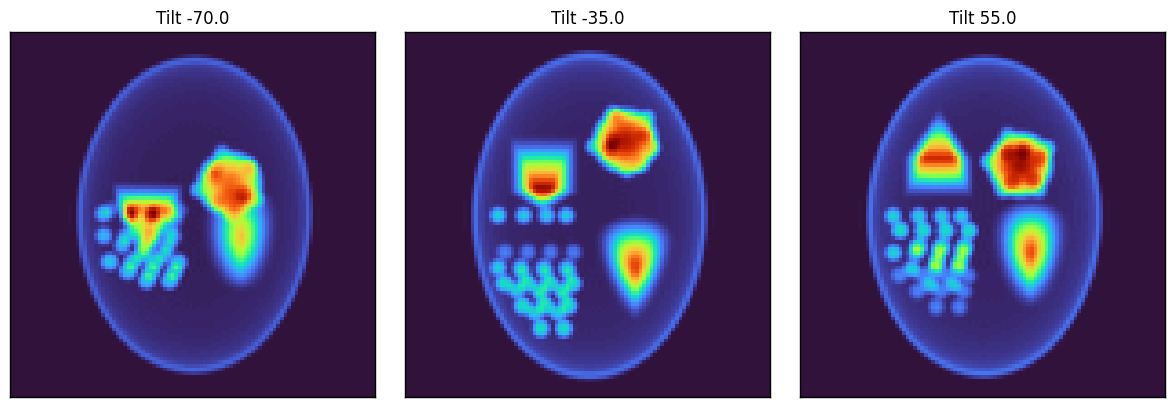

In [4]:
show_2d(
    [tilt_series[0], tilt_series[7], tilt_series[25]],
    title = [f'Tilt {tilt_angles[0]}', f'Tilt {tilt_angles[7]}', f'Tilt {tilt_angles[25]}'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# Conventional Tomography Reconstructions

In [5]:
# Initialize dataset
dset = TomographyPixDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

In [6]:
# Initialize object

obj_pix = ObjectPixelated.from_uniform(
    shape = (100, 100, 100), 
    device = device,
)

In [7]:
# Initialize conventional tomography object

tomo_conv = TomographyConventional.from_models(
    dset = dset,
    obj_model = obj_pix,
    device = device,
)

In [8]:
# Define Constraints (currently for conventional algorithms, only constraints to the objects are supported)

obj_constraints = ObjConstraintParams.ObjPixelatedConstraints(
    positivity = True,
    shrinkage = 0,
    tv_vol = 0,
)

In [9]:
tomo_conv.reconstruct(
    num_iter = 10,
    obj_constraints = obj_constraints,
    inline_alignment = True,
    smoothing_sigma = 0.5,
)

sirt Reconstruction | Loss: 0.0262: 100%|██████████| 10/10 [00:06<00:00,  1.56it/s]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Conventional Reconstruction Summed X'}>,
        <Axes: title={'center': 'Conventional Reconstruction Summed Y'}>,
        <Axes: title={'center': 'Conventional Reconstruction Summed Z'}>],
       dtype=object))

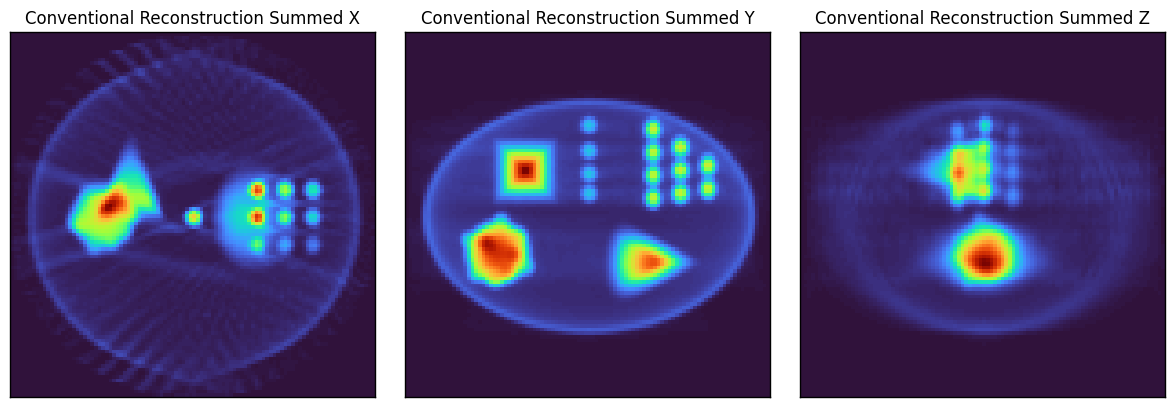

In [10]:
show_2d(
    [obj_pix.obj.sum(axis = 0), obj_pix.obj.sum(axis = 1), obj_pix.obj.sum(axis = 2)],
    cmap = 'turbo',
    title = ['Conventional Reconstruction Summed X', 'Conventional Reconstruction Summed Y', 'Conventional Reconstruction Summed Z'],
    vmin = 0,
    vmax = None,
)

# INR-Based Tomography Reconstruction

In [11]:
dset = TomographyINRDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

In [12]:
# Initialize INR Model
model = HSiren(alpha = 1, winner_initialization = True)

# Initialize INR Object
obj_inr = ObjectINR.from_model(
    shape = (100, 100, 100),
    device = device,
    model = model,
)


Model built, compiled successfully


In [13]:
# Define a logger
logger = LoggerTomography(
    log_dir = "../../../outputs/tomography/tutorial_02_notebooks/",
    run_prefix = "inr_tomography",
    run_suffix = "",
    log_images_every = 2,
)

In [2]:
# Initialize INR-Based Tomography Object
tomo_inr = Tomography.from_models(
    dset = dset,
    obj_model = obj_inr,
    device = device,
    logger = logger,
)

NameError: name 'Tomography' is not defined

In [15]:
# Define optimizer and scheduler parameters

# optimizer_params = {
#     "object": {
#         "type": "adam", # Optimizer type.
#         "lr": 1e-4, # Learning rate.
#     },
#     "pose": {
#         "type": "adam", # Optimizer type.
#         "lr": 1e-2, # Learning rate.
#     }
# }

optimizer_params = {
    "object": OptimizerParams.Adam(
        lr = 5e-5,
    ),
    "pose": OptimizerParams.Adam(
        lr = 1e-2,
    )
}
"""
All available scheduler params are in `core/ml/optimizer_mixin.py`

Scheduler types: 'cyclic', 'plateau', 'exp', 'gamma', 'linear', 'cosine_annealing'
Keyword arguments follow PyTorch scheduler documentation.
"""

scheduler_params = {
    "object": SchedulerParams.Plateau(
        mode = "min",
        factor = 0.5,
        patience = 10,
        threshold = 1e-3,
        min_lr = 1e-7,
    ),
    "pose": SchedulerParams.Plateau(
        mode = "min",
        factor = 0.5,
        patience = 10,
        threshold = 1e-3,
        min_lr = 1e-7,
    )
}

"""
Defining the constraints that we want to apply to the object and dataset. In this case
adding a total-variational loss, enforcing positivity, and a shrinkage constraint.

For the dataset we can add a 1-D total-variational loss to the shifts and z-shifts.
However this may not be necessary depending on the dataset.
"""

obj_constraints = ObjConstraintParams.ObjINRConstraints(
    positivity = True,
    sparsity = 1e-6,
    tv_vol = 1e-4,
)

## Dataset constraints not necessarily needed.

dataset_constraints = DatasetConstraintParams.BaseTomographyDatasetConstraints(
    tv_shifts = 1e-6, # 1-D regularizer for the shift optimization
    tv_zs = 1e-6, # 1-D regularizer for the z-shift optimization.
)


Now we can call the reconstruct function. `Tomography.reconstruct` has additional arguments such as the `num_samples_per_ray` which is the number of samples each ray will have. **It is recommended to set the number of samples to the max dim of your tilt stack, i.e (72, 200, 200) the final samples per ray will be 200**.

In [1]:
# Reconstruct

tomo_inr.reconstruct(
    num_iter = 20,
    batch_size = 1024,
    num_workers = 32,
    reset = False,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    obj_constraints = obj_constraints,
    dset_constraints = dataset_constraints,
    num_samples_per_ray = 100,
    val_fraction = 0.0,
    loss_type = "l2",
    loss_func_kwargs = {},
    reset_dset = None,
)

NameError: name 'tomo_inr' is not defined

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
       dtype=object))

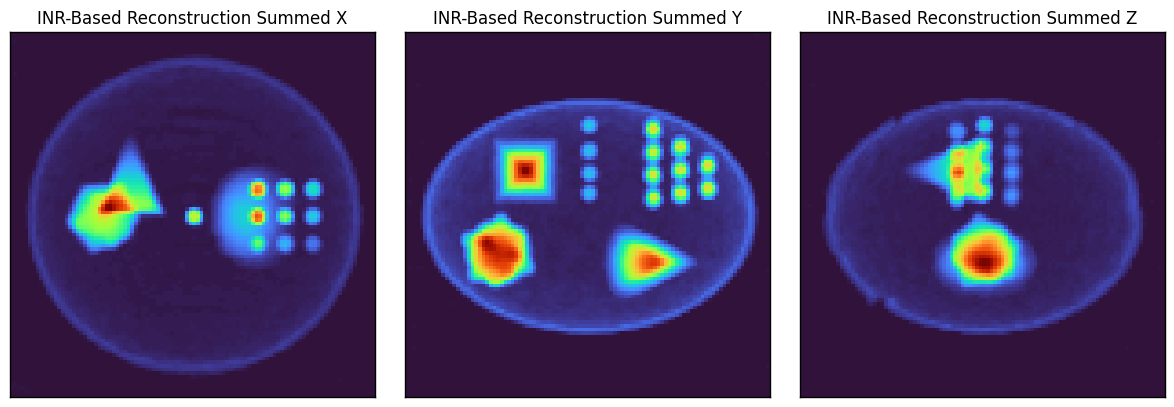

In [26]:
obj = tomo_inr.obj_model.obj_view[0]

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    title = ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

## Continuing Training

If the volume is not converged yet, you can continue training by calling another `.reconstruct` call. Exisiting dataloaders will not be reinitialized

In [27]:
tomo_inr.reconstruct(
    num_iter = 20
)


  0%|          | 0/20 [00:00<?, ?it/s]

Reconstruction | Loss: 7.94104e-04, Consistency Loss: 2.11576e-04, Soft Constraint Loss: 5.82529e-04 | Images Logged: 100%|██████████| 20/20 [01:48<00:00,  5.42s/it]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
       dtype=object))

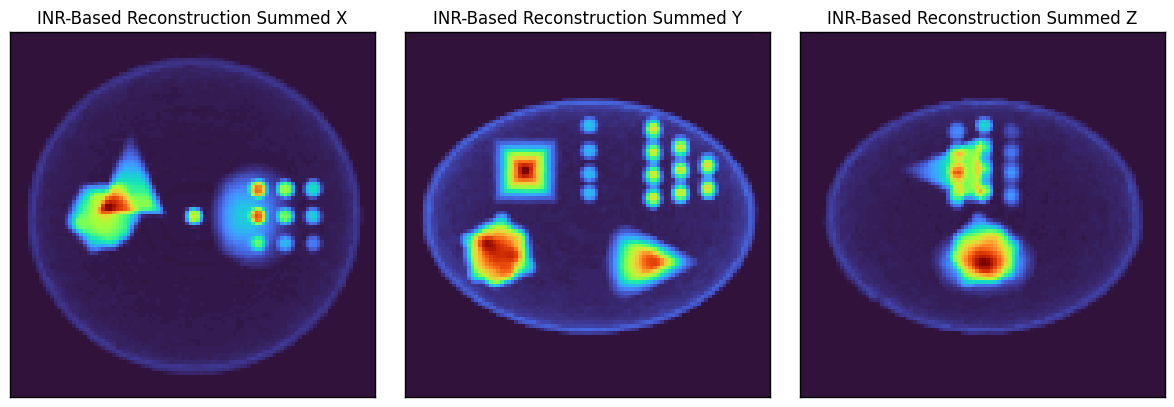

In [29]:
obj = tomo_inr.obj_model.obj_view[0]

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    title = ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# Saving the Full Object and/or Final Reconstructed Volume

Saving the full tomography object keeps the model, optimizer, and scheduler parameters along with their respective gradients allowing for continued training. There is also an option just to save the final reconstructed volume.

Currently, `MultiProcessingDataLoaders` cannot be saved, so we must skip and reinitialize the dataloader.

In [30]:
tomo_inr.save("../../../outputs/tomography/tutorial_02_notebooks/tomo_inr.zip", skip = ["dataloader"], mode = 'o')

falling back in serialize for _device of type <class 'torch.device'>
falling back in serialize for object of type <class 'quantem.core.ml.optimizer_mixin.SchedulerParams.Plateau'>
falling back in serialize for pose of type <class 'quantem.core.ml.optimizer_mixin.SchedulerParams.Plateau'>


In [6]:
tomo = Tomography.from_file("../../../outputs/tomography/tutorial_02_notebooks/tomo_inr.zip", device = device)

Dataloader setup complete:
  Total train samples: 290000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 283


In [32]:
tomo.reconstruct(num_iter = 10)

Reconstruction | Loss: 6.97312e-04, Consistency Loss: 1.79442e-04, Soft Constraint Loss: 5.17869e-04 | Images Logged: 100%|██████████| 10/10 [00:55<00:00,  5.52s/it]


In [ ]:
show_2d(
    [
        [tomo_inr.obj_model.obj_view[0].sum(axis = 0), tomo_inr.obj_model.obj_view[0].sum(axis = 1), tomo_inr.obj_model.obj_view[0].sum(axis = 2)],
        [tomo.obj_model.obj_view[0].sum(axis = 0), tomo.obj_model.obj_view[0].sum(axis = 1), tomo.obj_model.obj_view[0].sum(axis = 2)],
    ],
    title = [
        ['Summed X T = 40', 'Summed Y T = 40', 'Summed Z T = 40'],
        ['Summed X T = 50', 'Summed Y T = 50', 'Summed Z T = 50'],
    ],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

## Saving Volume

In [ ]:
tomo_inr.save_volume("../../../outputs/tomography/tutorial_02_notebooks/recon_volume.npz")

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Saved Volume Summed X'}>,
        <Axes: title={'center': 'Saved Volume Summed Y'}>,
        <Axes: title={'center': 'Saved Volume Summed Z'}>], dtype=object))

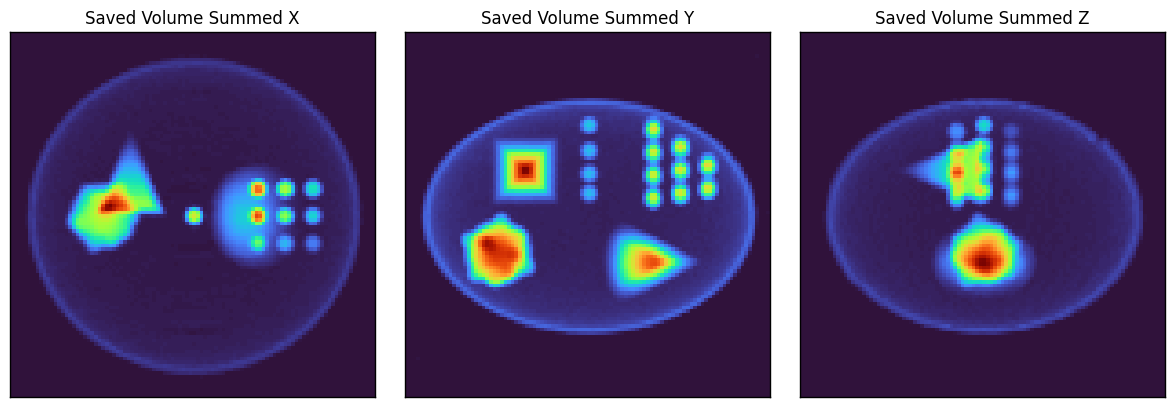

In [8]:
saved_vol = np.load("../../../outputs/tomography/tutorial_02_notebooks/recon_volume.npz")["volume"]
show_2d(
    [
        saved_vol[0].sum(axis = 0), saved_vol[0].sum(axis = 1), saved_vol[0].sum(axis = 2),
    ],
    title = [
        "Saved Volume Summed X",
        "Saved Volume Summed Y",
        "Saved Volume Summed Z",
    ],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

## Training Strategies

For these reconstructions one could implement warmup, different scheduler training, or pretraining strategies. A few examples are shown below

### Warmup to CosineAnneal

In [5]:
"""
Run if previous cells were run.
"""
import torch.multiprocessing as mp

for p in mp.active_children():
    p.terminate()
    p.join()

torch.cuda.empty_cache()

In [10]:
dset = TomographyINRDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

# Initialize INR Model
model = HSiren(alpha = 1, winner_initialization = True)

# Initialize INR Object
obj_inr = ObjectINR.from_model(
    shape = (100, 100, 100),
    device = device,
    model = model,
)

# Define a logger
logger = LoggerTomography(
    log_dir = "../../../outputs/tomography/tutorial_02_notebooks/",
    run_prefix = "inr_tomography_warmup_cosineanneal",
    run_suffix = "1",
    log_images_every = 2,
)

# Initialize INR-Based Tomography Object
tomo_inr = Tomography.from_models(
    dset = dset,
    obj_model = obj_inr,
    device = device,
    logger = logger,
)

Model built, compiled successfully
Setting up DDP for obj_model


In [17]:
# Define optimizer and scheduler parameters - only optimizing the object.

# Optimizers and schedulers can also be defined as dictionaries.
optimizer_params = {
    "object": {
        "type": "adam",
        "lr": 1e-4,
    },
}

scheduler_params = {
    "object": {
        "type": "linear",
    },
}

# Define constraints, can also be defined as dictionaries.

obj_constraints = {
    "name": "obj_inr",
    "tv_vol": 1e-4,
    "positivity": True,
    "sparsity": 1e-6,
}

dset_constraints = {
    "type": "base_tomography_dataset",
    "tv_shifts": 1e-6,
    "tv_zs": 1e-6,
}

# Warmup Schedule for 10 epochs

num_samples_per_ray = [
    (0, 20),
    (1, 20),
    (2, 40),
    (3, 40),
    (4, 60),
    (4, 60),
    (6, 80),
    (7, 80),
    (8, 100),
    (9, 100),
]


In [ ]:
tomo_inr.reconstruct(
    num_iter = 10,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
    num_samples_per_ray = num_samples_per_ray,
    num_workers = 32,
)


In [19]:
# Initialzie pose optimizer 

optimizer_params = {
    "pose": {
        "type": "adam",
        "lr": 1e-2,
    }
}

# Define new schedulers for both optimizers using CosineAnnealing
scheduler_params = {
    "object": {
        "type": "cosine_annealing",
    },
    "pose": {
        "type": "cosine_annealing",
    }
}

In [23]:
tomo_inr.dset.constraints

DatasetConstraintParams.BaseTomographyDatasetConstraints(tv_zs=1e-06, tv_shifts=1e-06)

In [ ]:
# Reconstruct

tomo_inr.reconstruct(
    num_iter = 30,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    num_samples_per_ray = 100,
)


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
       dtype=object))

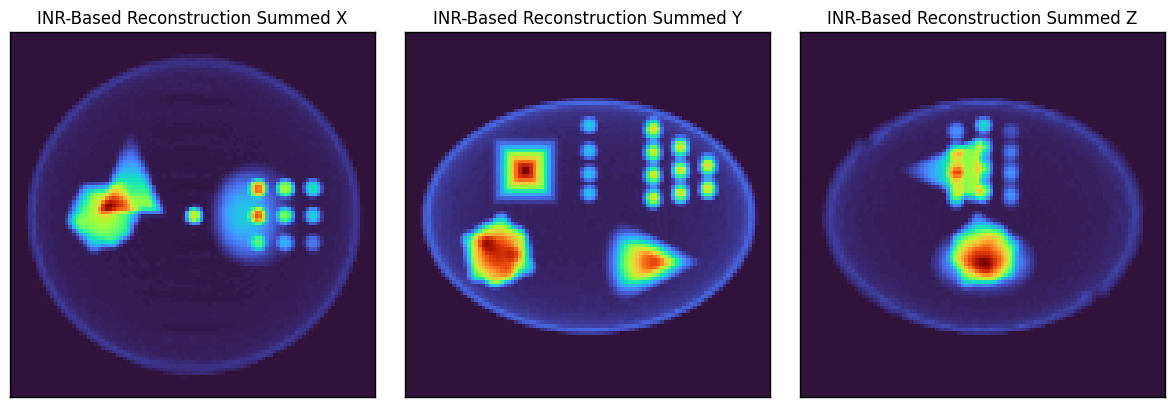

In [27]:
obj = tomo_inr.obj_model.obj_view[0]

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    title = ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

### Pretraining

Convergence can be achieved faster by pretraining the INR object on a conventional algorithm.

In [ ]:
"""
Run if previous cells were run.
"""
import torch.multiprocessing as mp

for p in mp.active_children():
    p.terminate()
    p.join()

torch.cuda.empty_cache()

In [ ]:
dset = TomographyPixDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

obj_pix = ObjectPixelated.from_uniform(
    shape = (100, 100, 100),
    device = device,
)

tomo_conv = TomographyConventional.from_models(
    dset = dset,
    obj_model = obj_pix,
)

tomo_conv.reconstruct(
    num_iter = 10,
    inline_alignment = True,
    smoothing_sigma = 0.5,
)

In [ ]:
show_2d(
    [obj_pix.obj_view[0].sum(axis = 0), obj_pix.obj_view[0].sum(axis = 1), obj_pix.obj_view[0].sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

obj_pix.obj.max()

In [ ]:
obj_pix_pretrain = obj_pix.obj_view

# Transpose to INR coordinates
obj_pix_pretrain = torch.from_numpy(obj_pix_pretrain.transpose(0, 2, 3, 1))
obj_pix_pretrain = obj_pix_pretrain.to(obj_pix.obj.device)

show_2d(
    [obj_pix_pretrain[0].sum(axis = 0), obj_pix_pretrain[0].sum(axis = 1), obj_pix_pretrain[0].sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
    title = ["Pretrain Object Summed X", "Pretrain Object Summed Y", "Pretrain Object Summed Z"]
)


SIRT and INR have different intensity scales for some reason, so you have to rescale the SIRT by a factor of ~42

In [ ]:
model = HSiren(alpha = 1, winner_initialization = True)

obj_inr = ObjectINR.from_model(
    shape = (100, 100, 100),
    device = device,
    model = model,
)

pretrain_dset = TomographyINRPretrainDataset(
    pretrain_target = obj_pix_pretrain,
)

optimizer_params = {
    "type": "adam",
    "lr": 1e-5,
}

scheduler_params = {
    "type": "plateau",
}



In [ ]:
obj_inr.pretrain(
    pretrain_dataset = pretrain_dset,
    num_iters = 30,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    loss_fn = "l2",
    batch_size = 1024,
    num_workers = 32,
)



In [ ]:
obj = obj_inr.obj_view[0]
show_2d(
    [
        [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
        [obj_pix.obj_view[0].sum(axis = 0), obj_pix.obj_view[0].sum(axis = 1), obj_pix.obj_view[0].sum(axis = 2)],
    ],
    title = [
        ["INR Pretrained Reconstruction Summed X", "INR Pretrained Reconstruction Summed Y", "INR Pretrained Reconstruction Summed Z"],
        ["Conventional Reconstruction Summed X", "Conventional Reconstruction Summed Y", "Conventional Reconstruction Summed Z"],
    ],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)


In [ ]:
# Reconstruct using the same pretrained object
dset = TomographyINRDataset.from_data(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

# Define a logger
logger = LoggerTomography(
    log_dir = "../../../outputs/tomography/tutorial_02/",
    run_prefix = "inr_tomography_pretrained",
    run_suffix = "1",
    log_images_every = 2,
)
tomo_inr = Tomography.from_models(
    dset = dset,
    obj_model = obj_inr,
    device = device,
    logger = logger,
)

In [ ]:
# Define optimizer and scheduler parameters

optimizer_params = {
    "object": {
        "type": "adam",
        "lr": 1e-4,
    },
    "pose": {
        "type": "adam",
        "lr": 1e-2,
    }
}

scheduler_params = {
    "object": {
        "type": "cosine_annealing",
    },
    "pose": {
        "type": "cosine_annealing",
    }
}

obj_constraints = {
    "tv_vol": 5e-7,
    "positivity": True,
    "sparsity": 1e-6,
}

dset_constraints = {
    "tv_shifts": 1e-6,
    "tv_zs": 1e-6,
}


In [ ]:
tomo_inr.reconstruct(
    num_iter = 30,
    optimizer_params = optimizer_params,
    scheduler_params = scheduler_params,
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
    num_samples_per_ray = 100,
)



In [ ]:
obj = tomo_inr.obj_model.obj_view[0]

show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    title = ["INR Pretrained Reconstruction Summed X", "INR Pretrained Reconstruction Summed Y", "INR Pretrained Reconstruction Summed Z"],
    vmin = 0,
    vmax = None,
)